Device: cuda
Dataset shape: (222074, 7)
                                             Reviews  MedicineFor  IntakeTime  \
0  actually i use the generic brand of the hour n...         1749        4400   
1  cap took minutes to open process was frustrati...         1749        4406   
2  hi everyone htpfor anxietyoctgannutaken for le...         1274        4406   
3  took ssri prozac for anxietydepression for yea...         1274        4399   
4  i have been suffering from severe panic disord...         1274        4406   

   ReviewLength  NumberOfLikes  Rating  label  
0     -0.104701      -0.545990      10      1  
1      0.101196      -0.545990       1      0  
2      1.054425       6.736677      10      1  
3     -0.726206       4.288012       9      1  
4      1.363271       4.034702      10      1  
label
1    139854
0     82220
Name: count, dtype: int64
Train shape: (177659, 6)
Test shape: (44415, 6)
Vocab size: 40000
Loaded GloVe words: 400000
Train text shape: (177659, 220)
Trai

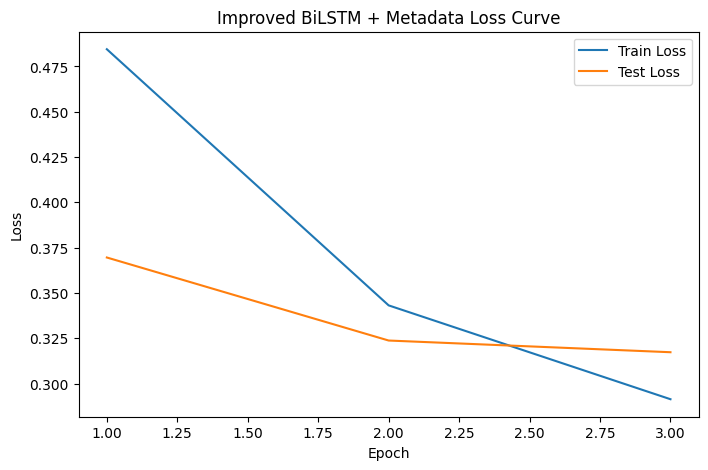

Device: cuda
Dataset shape: (243475, 7)
                                             Reviews  MedicineFor  IntakeTime  \
0  this is very effective if you can get the cove...         1749        4399   
1  actually i use the generic brand of the hour n...         1749        4400   
2  cap took minutes to open process was frustrati...         1749        4406   
3  hi everyone htpfor anxietyoctgannutaken for le...         1274        4406   
4  took ssri prozac for anxietydepression for yea...         1274        4399   

   ReviewLength  NumberOfLikes  Rating  label  
0     -1.122749      -0.545990       6      1  
1     -0.104701      -0.545990      10      2  
2      0.101196      -0.545990       1      0  
3      1.054425       6.736677      10      2  
4     -0.726206       4.288012       9      2  
label
2    139854
0     82220
1     21401
Name: count, dtype: int64
Train shape: (194780, 6)
Test shape: (48695, 6)
Vocab size: 40000
Loading GloVe...
Loaded GloVe words: 400000
Embeddi

C:\Users\shuva\AppData\Local\Temp\ipykernel_26012\2376855294.py:421: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_cnn_bilstm_glove300


Final CNN + BiLSTM + Metadata + GloVe300 Results
Accuracy : 0.7870417907382689
Precision: 0.7555532024465761
Recall   : 0.7870417907382689
F1       : 0.7524515694878632

Classification Report
              precision    recall  f1-score   support

    negative       0.73      0.81      0.77     16444
     neutral       0.42      0.01      0.01      4280
    positive       0.82      0.89      0.86     27971

    accuracy                           0.79     48695
   macro avg       0.66      0.57      0.55     48695
weighted avg       0.76      0.79      0.75     48695



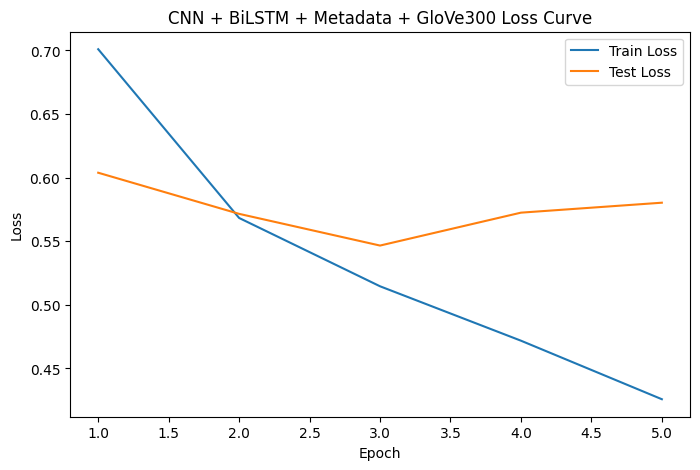

In [1]:
# =========================================================
# CNN + BiLSTM + Metadata + GloVe 300d
# 3-Class Sentiment Classification
# =========================================================

import pandas as pd
import numpy as np
import random
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from collections import Counter
import matplotlib.pyplot as plt

# -------------------------
# 1. Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# 2. Load dataset
# -------------------------
FILE_PATH = "three_class_dataset.csv"   # change this only
df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
print(df.head())
print(df["label"].value_counts())

# -------------------------
# 3. Keep required columns
# -------------------------
df = df[[
    "Reviews",
    "MedicineFor",
    "IntakeTime",
    "ReviewLength",
    "NumberOfLikes",
    "label"
]].copy()

df["Reviews"] = df["Reviews"].astype(str)

# -------------------------
# 4. Train-test split
# -------------------------
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# -------------------------
# 5. Tokenizer
# -------------------------
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

# -------------------------
# 6. Build vocabulary
# -------------------------
counter = Counter()
for text in train_df["Reviews"]:
    counter.update(tokenize(text))

MAX_VOCAB_SIZE = 40000
special_tokens = ["<PAD>", "<UNK>"]

most_common = counter.most_common(MAX_VOCAB_SIZE - len(special_tokens))
vocab = {word: idx + len(special_tokens) for idx, (word, _) in enumerate(most_common)}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

print("Vocab size:", len(vocab))

# -------------------------
# 7. Load GloVe 300d
# -------------------------
GLOVE_PATH = "glove.6B.300d.txt"   # change path if needed
EMBED_DIM = 300

print("Loading GloVe...")
glove_dict = {}

with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove_dict[word] = vector

print("Loaded GloVe words:", len(glove_dict))

# -------------------------
# 8. Create embedding matrix
# -------------------------
embedding_matrix = np.zeros((len(vocab), EMBED_DIM))

for word, idx in vocab.items():
    if word in glove_dict:
        embedding_matrix[idx] = glove_dict[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)
print("Embedding matrix shape:", embedding_matrix.shape)

# -------------------------
# 9. Convert text to sequences
# -------------------------
MAX_LEN = 180

def text_to_sequence(text, vocab, max_len=180):
    tokens = tokenize(text)
    seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    if len(seq) < max_len:
        seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return seq

train_sequences = np.array([text_to_sequence(text, vocab, MAX_LEN) for text in train_df["Reviews"]])
test_sequences  = np.array([text_to_sequence(text, vocab, MAX_LEN) for text in test_df["Reviews"]])

# -------------------------
# 10. Metadata
# categorical -> embeddings
# numeric -> dense branch
# -------------------------
X_train_meta = train_df[["ReviewLength", "NumberOfLikes"]].values.astype(np.float32)
X_test_meta  = test_df[["ReviewLength", "NumberOfLikes"]].values.astype(np.float32)

train_medicinefor = train_df["MedicineFor"].values.astype(np.int64)
test_medicinefor  = test_df["MedicineFor"].values.astype(np.int64)

train_intaketime = train_df["IntakeTime"].values.astype(np.int64)
test_intaketime  = test_df["IntakeTime"].values.astype(np.int64)

y_train = train_df["label"].values
y_test  = test_df["label"].values

print("Train sequences shape:", train_sequences.shape)
print("Train numeric meta shape:", X_train_meta.shape)

# -------------------------
# 11. PyTorch Dataset
# -------------------------
class HybridTextDataset(Dataset):
    def __init__(self, text_sequences, meta_features, medicinefor, intaketime, labels):
        self.text_sequences = torch.tensor(text_sequences, dtype=torch.long)
        self.meta_features = torch.tensor(meta_features, dtype=torch.float32)
        self.medicinefor = torch.tensor(medicinefor, dtype=torch.long)
        self.intaketime = torch.tensor(intaketime, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.text_sequences[idx],
            self.meta_features[idx],
            self.medicinefor[idx],
            self.intaketime[idx],
            self.labels[idx]
        )

train_dataset = HybridTextDataset(
    train_sequences,
    X_train_meta,
    train_medicinefor,
    train_intaketime,
    y_train
)

test_dataset = HybridTextDataset(
    test_sequences,
    X_test_meta,
    test_medicinefor,
    test_intaketime,
    y_test
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -------------------------
# 12. Model
# -------------------------
class CNNBiLSTMWithMetadata(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_matrix,
        embed_dim,
        cnn_filters,
        kernel_size,
        hidden_dim,
        output_dim,
        num_layers,
        dropout,
        medicinefor_vocab_size,
        intaketime_vocab_size,
        cat_embed_dim,
        numeric_input_dim,
        numeric_hidden_dim
    ):
        super(CNNBiLSTMWithMetadata, self).__init__()

        # Text embedding with GloVe
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False,
            padding_idx=0
        )

        # CNN branch
        self.conv1d = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=cnn_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=cnn_filters,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Categorical metadata embeddings
        self.medicinefor_embedding = nn.Embedding(medicinefor_vocab_size + 1, cat_embed_dim)
        self.intaketime_embedding = nn.Embedding(intaketime_vocab_size + 1, cat_embed_dim)

        # Numeric metadata branch
        self.numeric_fc = nn.Sequential(
            nn.Linear(numeric_input_dim, numeric_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        fusion_dim = hidden_dim * 2 + cat_embed_dim + cat_embed_dim + numeric_hidden_dim

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(fusion_dim, output_dim)

    def forward(self, text, meta_numeric, medicinefor, intaketime):
        # Text embedding
        x = self.embedding(text)                      # [batch, seq_len, embed_dim]

        # CNN
        x = x.permute(0, 2, 1)                       # [batch, embed_dim, seq_len]
        x = torch.relu(self.conv1d(x))               # [batch, cnn_filters, seq_len]
        x = x.permute(0, 2, 1)                       # [batch, seq_len, cnn_filters]

        # BiLSTM
        lstm_out, (hidden, cell) = self.lstm(x)

        forward_hidden = hidden[-2, :, :]
        backward_hidden = hidden[-1, :, :]
        text_features = torch.cat((forward_hidden, backward_hidden), dim=1)

        # Metadata
        medicinefor_features = self.medicinefor_embedding(medicinefor)
        intaketime_features = self.intaketime_embedding(intaketime)
        numeric_features = self.numeric_fc(meta_numeric)

        # Combine
        combined = torch.cat(
            (text_features, medicinefor_features, intaketime_features, numeric_features),
            dim=1
        )

        combined = self.dropout(combined)
        out = self.fc(combined)

        return out

VOCAB_SIZE = len(vocab)
CNN_FILTERS = 128
KERNEL_SIZE = 5
HIDDEN_DIM = 256
OUTPUT_DIM = 3
NUM_LAYERS = 1
DROPOUT = 0.5

MEDICINEFOR_VOCAB_SIZE = int(df["MedicineFor"].max())
INTAKETIME_VOCAB_SIZE = int(df["IntakeTime"].max())
CAT_EMBED_DIM = 32
NUMERIC_INPUT_DIM = 2
NUMERIC_HIDDEN_DIM = 32

model = CNNBiLSTMWithMetadata(
    vocab_size=VOCAB_SIZE,
    embedding_matrix=embedding_matrix,
    embed_dim=EMBED_DIM,
    cnn_filters=CNN_FILTERS,
    kernel_size=KERNEL_SIZE,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    medicinefor_vocab_size=MEDICINEFOR_VOCAB_SIZE,
    intaketime_vocab_size=INTAKETIME_VOCAB_SIZE,
    cat_embed_dim=CAT_EMBED_DIM,
    numeric_input_dim=NUMERIC_INPUT_DIM,
    numeric_hidden_dim=NUMERIC_HIDDEN_DIM
).to(device)

print(model)

# -------------------------
# 13. Loss and optimizer
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

# -------------------------
# 14. Training loop
# -------------------------
EPOCHS = 5
train_losses = []
test_losses = []

best_val_loss = float("inf")
patience = 2
counter = 0

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in train_loader:
        text_batch = text_batch.to(device)
        meta_batch = meta_batch.to(device)
        medicinefor_batch = medicinefor_batch.to(device)
        intaketime_batch = intaketime_batch.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in test_loader:
            text_batch = text_batch.to(device)
            meta_batch = meta_batch.to(device)
            medicinefor_batch = medicinefor_batch.to(device)
            intaketime_batch = intaketime_batch.to(device)
            labels = labels.to(device)

            outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test Loss : {avg_test_loss:.4f}")
    print(f"Accuracy  : {acc:.4f}")
    print("-" * 40)

    if avg_test_loss < best_val_loss:
        best_val_loss = avg_test_loss
        counter = 0
        torch.save(model.state_dict(), "best_cnn_bilstm_glove300.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# -------------------------
# 15. Load best model
# -------------------------
model.load_state_dict(torch.load("best_cnn_bilstm_glove300.pt"))

# -------------------------
# 16. Final evaluation
# -------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in test_loader:
        text_batch = text_batch.to(device)
        meta_batch = meta_batch.to(device)
        medicinefor_batch = medicinefor_batch.to(device)
        intaketime_batch = intaketime_batch.to(device)
        labels = labels.to(device)

        outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print("\nFinal CNN + BiLSTM + Metadata + GloVe300 Results")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)

print("\nClassification Report")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["negative", "neutral", "positive"],
    zero_division=0
))

# -------------------------
# 17. Loss curve
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1, len(test_losses)+1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + BiLSTM + Metadata + GloVe300 Loss Curve")
plt.legend()
plt.show()